In [1]:
import os
import re
import pandas as pd
from collections import defaultdict

BASE_DIR = "results_docking"

# regex to capture vina affinity lines
affinity_pattern = re.compile(r"^\s*1\s+(-?\d+\.\d+)\s+")

data = []

for protein in os.listdir(BASE_DIR):
    protein_path = os.path.join(BASE_DIR, protein)
    if not os.path.isdir(protein_path):
        continue

    for ligand in os.listdir(protein_path):
        ligand_path = os.path.join(protein_path, ligand)
        if not os.path.isdir(ligand_path):
            continue

        for file in os.listdir(ligand_path):
            if not file.endswith(".log"):
                continue

            log_path = os.path.join(ligand_path, file)

            # extract replicate number if exists
            rep_match = re.search(r"rep(\d+)", file)
            rep = int(rep_match.group(1)) if rep_match else None

            affinity = None

            with open(log_path, "r") as f:
                for line in f:
                    m = affinity_pattern.match(line)
                    if m:
                        affinity = float(m.group(1))
                        break

            if affinity is not None:
                data.append({
                    "protein": protein,
                    "ligand": ligand,
                    "replicate": rep,
                    "affinity": affinity
                })

df = pd.DataFrame(data)


In [2]:
df["ligand"].unique()


array(['10176710', '10394', '104775', '10559720', '107', '175', '348154',
       '439435', '49831816', '6262', '689043', '9877619', 'm1', 'm2',
       'm3', 'm4', 'm5', 'rf', 'rolR', 'rolS'], dtype=object)

In [2]:
# ---- per ligand mean/std ----
summary = (
    df.groupby(["protein", "ligand"])
      .agg(mean_affinity=("affinity", "mean"),
           std_affinity=("affinity", "std"),
           n=("affinity", "count"))
      .reset_index()
)

In [3]:
df[df["protein"] == "PDE4B_monomer"]

,protein,ligand,replicate,affinity
120,PDE4B_monomer,10176710,1,-7.7
121,PDE4B_monomer,10176710,2,-7.7
122,PDE4B_monomer,10176710,3,-7.7
123,PDE4B_monomer,10394,1,-6.5
124,PDE4B_monomer,10394,2,-6.5
125,PDE4B_monomer,10394,3,-6.5
126,PDE4B_monomer,104775,1,-3.9
127,PDE4B_monomer,104775,2,-3.9
128,PDE4B_monomer,104775,3,-3.9
129,PDE4B_monomer,10559720,1,-6.4


In [4]:
df.to_csv("vina_replicates.csv", index=False)
summary.to_csv("vina_summary.csv", index=False)

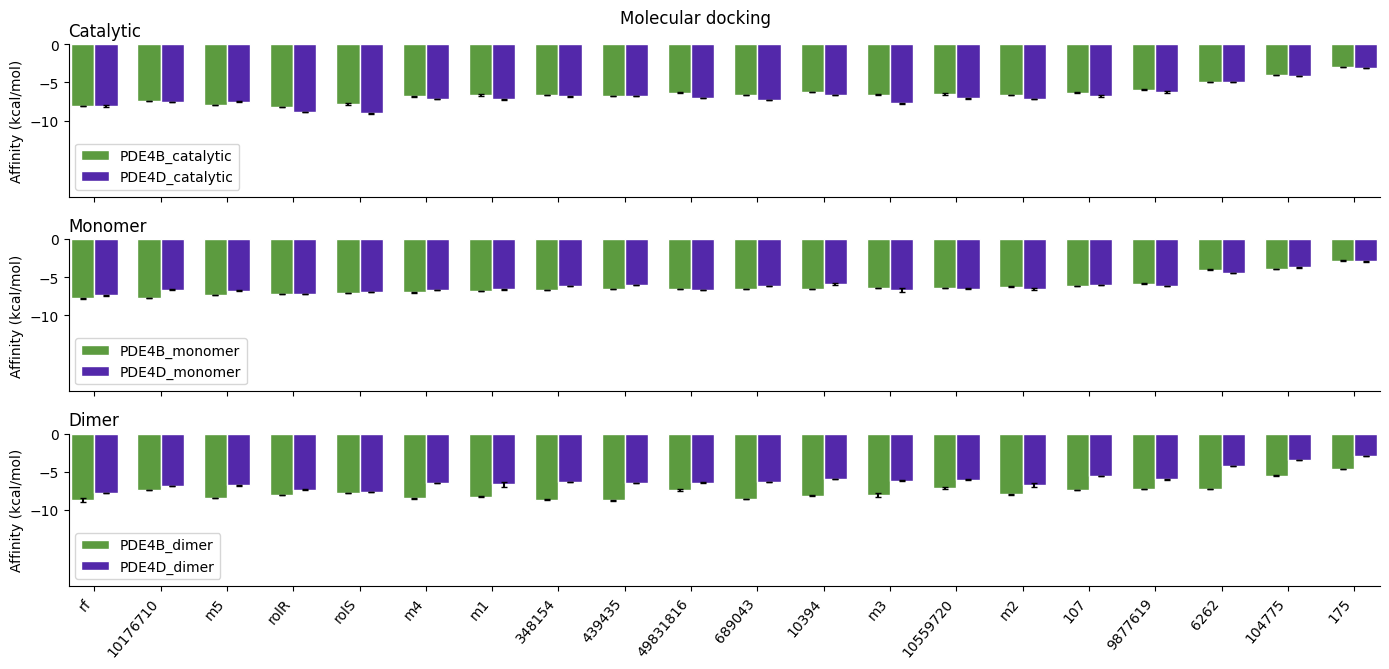

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# colors = {
#     "PDE4B_catalytic": "#a9d5a8",
#     "PDE4B_monomer": "#5c9b3f",
#     "PDE4B_dimer": "#306317",
#     "PDE4D_catalytic": "#9ea9e2",
#     "PDE4D_monomer": "#5328aa",
#     "PDE4D_dimer": "#2b0b63",
# }

colors = {
    "PDE4B_catalytic": "#5c9b3f",
    "PDE4B_monomer": "#5c9b3f",
    "PDE4B_dimer": "#5c9b3f",
    "PDE4D_catalytic": "#5328aa",
    "PDE4D_monomer": "#5328aa",
    "PDE4D_dimer": "#5328aa",
}

comparisons = [
    ("Catalytic", "PDE4B_catalytic", "PDE4D_catalytic"),
    ("Monomer", "PDE4B_monomer", "PDE4D_monomer"),
    ("Dimer", "PDE4B_dimer", "PDE4D_dimer"),
]

# Order ligands based on PDE4D_catalytic affinity: lowest → highest
# ligands = (
#     summary[summary["protein"] == "PDE4D_catalytic"]
#     .sort_values("mean_affinity", ascending=True)["ligand"]
#     .tolist()
# )
ligands = (
    summary[summary["protein"] == "PDE4B_monomer"]
    .sort_values("mean_affinity", ascending=True)["ligand"]
    .tolist()
)

x = np.arange(len(ligands))
width = 0.35

fig, axes = plt.subplots(
    3, 1,
    figsize=(14, 7),
    sharex=True,
    #gridspec_kw={"height_ratios": [1.5, 1.5, 2]}
)

for ax, (title, protein_b, protein_d) in zip(axes, comparisons):

    for i, protein in enumerate([protein_b, protein_d]):

        sub = (
            summary[summary["protein"] == protein]
            .set_index("ligand")
            .reindex(ligands)
        )

        ax.bar(
            x + (i - 0.5) * width,
            sub["mean_affinity"],
            width,
            yerr=sub["std_affinity"],
            capsize=2,
            label=protein,
            color=colors[protein],
            edgecolor="white",
            linewidth=1
        )
    ax.set_ylim(-20, 0)
    ax.set_yticks(np.arange(-10, 1, 5))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.margins(x=0.002)
    ax.set_ylabel("Affinity (kcal/mol)")
    ax.set_title(title, loc="left")
    ax.legend()

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(ligands, rotation=50, ha="right")

fig.suptitle("Molecular docking", y=0.95)
plt.tight_layout()
plt.show()

In [4]:
summary[summary["ligand"] == "m5"]

,protein,ligand,mean_affinity,std_affinity,n
16,PDE4B_catalytic,m5,-7.900000,0.000000,3
36,PDE4B_dimer,m5,-8.400000,0.000000,3
56,PDE4B_monomer,m5,-7.400000,0.000000,3
76,PDE4D_catalytic,m5,-7.533333,0.057735,3
96,PDE4D_dimer,m5,-6.766667,0.057735,3
116,PDE4D_monomer,m5,-6.766667,0.057735,3


In [5]:
summary[summary["ligand"] == "m4"]

,protein,ligand,mean_affinity,std_affinity,n
15,PDE4B_catalytic,m4,-6.833333,0.057735,3
35,PDE4B_dimer,m4,-8.500000,0.100000,3
55,PDE4B_monomer,m4,-6.966667,0.057735,3
75,PDE4D_catalytic,m4,-7.200000,0.000000,3
95,PDE4D_dimer,m4,-6.500000,0.000000,3
115,PDE4D_monomer,m4,-6.700000,0.000000,3


In [18]:
m4_pde4b_monomer = summary[(summary["ligand"] == "m4") & (summary["protein"] == "PDE4B_monomer")]["mean_affinity"].values[0]
m4_pde4d_monomer = summary[(summary["ligand"] == "m4") & (summary["protein"] == "PDE4D_monomer")]["mean_affinity"].values[0]

m4_pde4b_dimer = summary[(summary["ligand"] == "m4") & (summary["protein"] == "PDE4B_dimer")]["mean_affinity"].values[0]
m4_pde4d_dimer = summary[(summary["ligand"] == "m4") & (summary["protein"] == "PDE4D_dimer")]["mean_affinity"].values[0]

print(m4_pde4b_monomer - m4_pde4d_monomer) 
print(m4_pde4b_dimer - m4_pde4d_dimer)

-0.2666666666666657
-2.0


In [6]:
summary[summary["ligand"] == "m1"]

,protein,ligand,mean_affinity,std_affinity,n
12,PDE4B_catalytic,m1,-6.666667,0.152753,3
32,PDE4B_dimer,m1,-8.266667,0.057735,3
52,PDE4B_monomer,m1,-6.800000,0.000000,3
72,PDE4D_catalytic,m1,-7.233333,0.057735,3
92,PDE4D_dimer,m1,-6.666667,0.321455,3
112,PDE4D_monomer,m1,-6.600000,0.100000,3


In [20]:
m1_pde4b_monomer = summary[(summary["ligand"] == "m1") & (summary["protein"] == "PDE4B_monomer")]["mean_affinity"].values[0]
m1_pde4d_monomer = summary[(summary["ligand"] == "m1") & (summary["protein"] == "PDE4D_monomer")]["mean_affinity"].values[0]

m1_pde4b_dimer = summary[(summary["ligand"] == "m1") & (summary["protein"] == "PDE4B_dimer")]["mean_affinity"].values[0]
m1_pde4d_dimer = summary[(summary["ligand"] == "m1") & (summary["protein"] == "PDE4D_dimer")]["mean_affinity"].values[0]

print(m1_pde4b_monomer - m1_pde4d_monomer) 
print(m1_pde4b_dimer - m1_pde4d_dimer)

-0.1999999999999993
-1.6000000000000005


In [30]:
df.head(20)

,protein,ligand,replicate,affinity
0,PDE4B_catalytic,10176710,1,-7.4
1,PDE4B_catalytic,10176710,2,-7.4
2,PDE4B_catalytic,10176710,3,-7.4
3,PDE4B_catalytic,10394,1,-6.3
4,PDE4B_catalytic,10394,2,-6.3
5,PDE4B_catalytic,10394,3,-6.3
6,PDE4B_catalytic,104775,1,-4.0
7,PDE4B_catalytic,104775,2,-4.0
8,PDE4B_catalytic,104775,3,-4.0
9,PDE4B_catalytic,10559720,1,-6.4


In [2]:
# ---- per ligand 1st replicate ----
summary_1rep = (df.groupby(["protein", "ligand"]) \
    .agg(affinity=("affinity", "first"))   
    .reset_index())

In [3]:
summary_1rep

,protein,ligand,affinity
0,PDE4B_catalytic,10176710,-7.4
1,PDE4B_catalytic,10394,-6.3
2,PDE4B_catalytic,104775,-4.0
3,PDE4B_catalytic,10559720,-6.4
4,PDE4B_catalytic,107,-6.3
...,...,...,...
115,PDE4D_monomer,m4,-6.7
116,PDE4D_monomer,m5,-6.7
117,PDE4D_monomer,rf,-7.4
118,PDE4D_monomer,rolR,-7.2


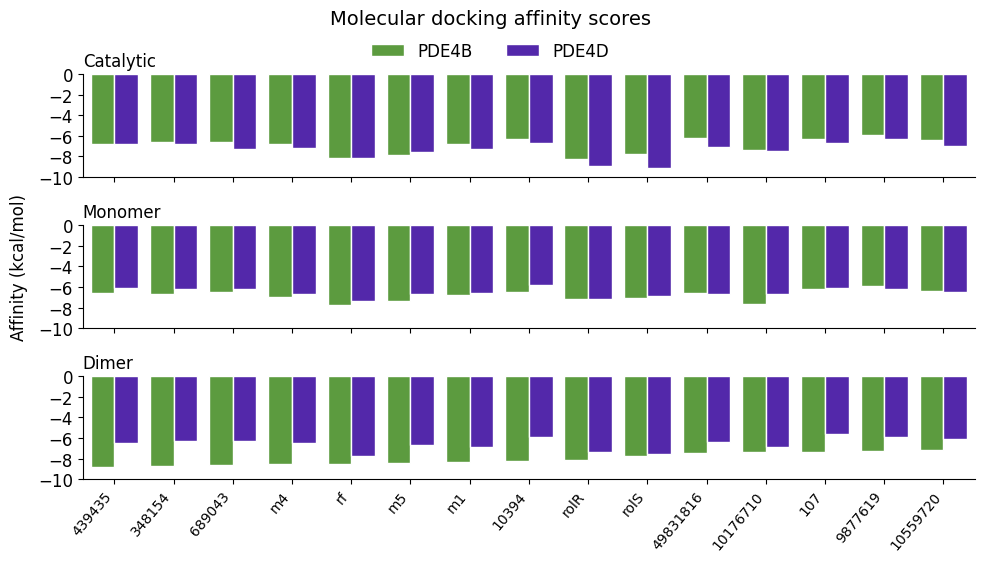

In [33]:
import matplotlib.pyplot as plt
import numpy as np

colors = {
    "PDE4B_catalytic": "#5c9b3f",
    "PDE4B_monomer": "#5c9b3f",
    "PDE4B_dimer": "#5c9b3f",
    "PDE4D_catalytic": "#5328aa",
    "PDE4D_monomer": "#5328aa",
    "PDE4D_dimer": "#5328aa",
}

comparisons = [
    ("Catalytic", "PDE4B_catalytic", "PDE4D_catalytic"),
    ("Monomer", "PDE4B_monomer", "PDE4D_monomer"),
    ("Dimer", "PDE4B_dimer", "PDE4D_dimer"),
]

ligands = (
    summary_1rep[summary_1rep["protein"] == "PDE4B_dimer"]
    .sort_values("affinity", ascending=True)["ligand"]
    .tolist()
)

to_remove = ["m3", "m2", "175", "104775","6262"]
ligands = [lig for lig in ligands if lig not in to_remove]

x = np.arange(len(ligands))
width = 0.4
fig, axes = plt.subplots(
    3, 1,
    figsize=(10, 6),
    sharex=True,
)

for ax, (title, protein_b, protein_d) in zip(axes, comparisons):
    for i, protein in enumerate([protein_b, protein_d]):
        sub = (
            summary_1rep[summary_1rep["protein"] == protein]
            .set_index("ligand")
            .reindex(ligands)
        )

        protein_clean = protein.split("_")[0]  # Remove the protein type (e.g., "catalytic", "monomer", "dimer")

        ax.bar(
            x + (i - 0.5) * width,
            sub["affinity"],
            width,
            capsize=2,
            label=protein_clean,
            color=colors[protein],
            edgecolor="white",
            linewidth=1
        )

    ax.set_ylim(-10, 0)
    ax.set_yticks(np.arange(-10, 1, 2))
    ax.tick_params(axis="y", labelsize=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.margins(x=0.009)
    ax.set_title(title, loc="left", size=12)
    #ax.legend()
    #ax.set_ylabel("Affinity (kcal/mol)")

# Create one shared legend using the labels from the first subplot
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.9),
    ncol=2,
    frameon=False,
    fontsize=12
)

fig.supylabel("Affinity (kcal/mol)", x=0.02, size=12)
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(ligands, rotation=50, ha="right", fontsize=10)

fig.suptitle("Molecular docking affinity scores", y=0.93, size=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [35]:
ligands

['439435',
 '348154',
 '689043',
 'm4',
 'rf',
 'm5',
 'm1',
 '10394',
 'rolR',
 'rolS',
 '49831816',
 '10176710',
 '107',
 '9877619',
 '10559720']

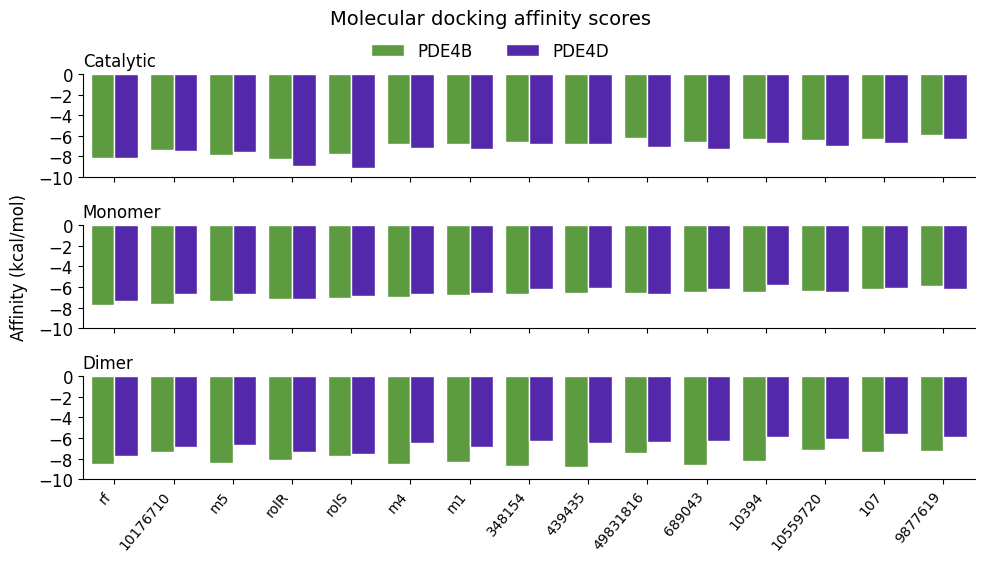

In [28]:
import matplotlib.pyplot as plt
import numpy as np

colors = {
    "PDE4B_catalytic": "#5c9b3f",
    "PDE4B_monomer": "#5c9b3f",
    "PDE4B_dimer": "#5c9b3f",
    "PDE4D_catalytic": "#5328aa",
    "PDE4D_monomer": "#5328aa",
    "PDE4D_dimer": "#5328aa",
}

comparisons = [
    ("Catalytic", "PDE4B_catalytic", "PDE4D_catalytic"),
    ("Monomer", "PDE4B_monomer", "PDE4D_monomer"),
    ("Dimer", "PDE4B_dimer", "PDE4D_dimer"),
]

ligands = (
    summary_1rep[summary_1rep["protein"] == "PDE4B_monomer"]
    .sort_values("affinity", ascending=True)["ligand"]
    .tolist()
)

to_remove = ["m3", "m2", "175", "104775","6262"]
ligands = [lig for lig in ligands if lig not in to_remove]

x = np.arange(len(ligands))
width = 0.4
fig, axes = plt.subplots(
    3, 1,
    figsize=(10, 6),
    sharex=True,
)

for ax, (title, protein_b, protein_d) in zip(axes, comparisons):
    for i, protein in enumerate([protein_b, protein_d]):
        sub = (
            summary_1rep[summary_1rep["protein"] == protein]
            .set_index("ligand")
            .reindex(ligands)
        )

        protein_clean = protein.split("_")[0]  # Remove the protein type (e.g., "catalytic", "monomer", "dimer")

        ax.bar(
            x + (i - 0.5) * width,
            sub["affinity"],
            width,
            capsize=2,
            label=protein_clean,
            color=colors[protein],
            edgecolor="white",
            linewidth=1
        )

    ax.set_ylim(-10, 0)
    ax.set_yticks(np.arange(-10, 1, 2))
    ax.tick_params(axis="y", labelsize=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.margins(x=0.009)
    ax.set_title(title, loc="left", size=12)
    #ax.legend()
    #ax.set_ylabel("Affinity (kcal/mol)")

# Create one shared legend using the labels from the first subplot
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.9),
    ncol=2,
    frameon=False,
    fontsize=12
)

fig.supylabel("Affinity (kcal/mol)", x=0.02, size=12)
axes[-1].set_xticks(x)
axes[-1].set_xticklabels(ligands, rotation=50, ha="right", fontsize=10)

fig.suptitle("Molecular docking affinity scores", y=0.93, size=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

,protein,ligand,affinity
0,PDE4B_catalytic,10176710,-7.4
1,PDE4B_catalytic,10394,-6.3
2,PDE4B_catalytic,104775,-4.0
3,PDE4B_catalytic,10559720,-6.4
4,PDE4B_catalytic,107,-6.3
...,...,...,...
115,PDE4D_monomer,m4,-6.7
116,PDE4D_monomer,m5,-6.7
117,PDE4D_monomer,rf,-7.4
118,PDE4D_monomer,rolR,-7.2


In [36]:
summary_1rep[summary_1rep["ligand"] == "10176710"]

,protein,ligand,affinity
0,PDE4B_catalytic,10176710,-7.4
20,PDE4B_dimer,10176710,-7.4
40,PDE4B_monomer,10176710,-7.7
60,PDE4D_catalytic,10176710,-7.5
80,PDE4D_dimer,10176710,-6.9
100,PDE4D_monomer,10176710,-6.7


In [37]:
summary_1rep[summary_1rep["ligand"] == "m5"]

,protein,ligand,affinity
16,PDE4B_catalytic,m5,-7.9
36,PDE4B_dimer,m5,-8.4
56,PDE4B_monomer,m5,-7.4
76,PDE4D_catalytic,m5,-7.6
96,PDE4D_dimer,m5,-6.7
116,PDE4D_monomer,m5,-6.7


In [10]:
summary_1rep[summary_1rep["ligand"] == "rf"]

,protein,ligand,affinity
17,PDE4B_catalytic,rf,-8.1
37,PDE4B_dimer,rf,-8.5
57,PDE4B_monomer,rf,-7.8
77,PDE4D_catalytic,rf,-8.1
97,PDE4D_dimer,rf,-7.8
117,PDE4D_monomer,rf,-7.4


In [44]:
summary_1rep[summary_1rep["ligand"] == "rolR"]

,protein,ligand,affinity
18,PDE4B_catalytic,rolR,-8.2
38,PDE4B_dimer,rolR,-8.1
58,PDE4B_monomer,rolR,-7.2
78,PDE4D_catalytic,rolR,-8.9
98,PDE4D_dimer,rolR,-7.4
118,PDE4D_monomer,rolR,-7.2


In [41]:
to_remove = ["m3", "m2"]
summary_1rep_18 = summary_1rep[
    ~summary_1rep["ligand"].isin(to_remove)
    & summary_1rep["protein"].str.startswith("PDE4B_")
]

# Media e desvio padrao da afinidade dos ligantes para cada estrutura da PDE4B
media_pde4b = (
    summary_1rep_18
    .groupby("protein", as_index=False)
    .agg(
        mean_affinity=("affinity", "mean"),
        std_affinity=("affinity", "std")
    )
    .round(2)
    .sort_values("protein")
)

media_pde4b

,protein,mean_affinity,std_affinity
0,PDE4B_catalytic,-6.44,1.37
1,PDE4B_dimer,-7.67,1.09
2,PDE4B_monomer,-6.29,1.35


In [43]:
# Melhor ligante em cada construto da PDE4B e sua afinidade no construto correspondente da PDE4D
summary_comparison = summary_1rep[
    ~summary_1rep["ligand"].isin(to_remove)
]

best_ligands_pde4b = []
for construct, protein_b, protein_d in comparisons:
    best_b = (
        summary_comparison[summary_comparison["protein"] == protein_b]
        .sort_values("affinity", ascending=True)
        .iloc[1]
    )
    affinity_d = summary_comparison.loc[
        (summary_comparison["protein"] == protein_d)
        & (summary_comparison["ligand"] == best_b["ligand"]),
        "affinity",
    ]

    best_ligands_pde4b.append({
        "construct": construct,
        "ligand": best_b["ligand"],
        "PDE4B_affinity": best_b["affinity"],
        "PDE4D_affinity": affinity_d.iloc[0] if not affinity_d.empty else np.nan,
    })

best_ligands_pde4b = pd.DataFrame(best_ligands_pde4b)
best_ligands_pde4b

,construct,ligand,PDE4B_affinity,PDE4D_affinity
0,Catalytic,rf,-8.1,-8.1
1,Monomer,10176710,-7.7,-6.7
2,Dimer,348154,-8.7,-6.3
